In [ ]:
from code.v2_data_preprocessing import(
    load_and_prepare_data, slice_by_dates, handle_duplicate_values, reindex_daily, handle_outliers, filter_by_reflectance,
    calculate_stats_from_random_points, filter_columns, handle_missing_values, smooth_data, obs_data)

from code.v2_daily_time_series_generation import generate_daily_landsat_series, plot_residuals_boxplot, plot_landsat_bands

from code.v2_features_processing import(
    process_spectral_data, principal_component_analysis, cross_correlations_analysis, merge_datasets,
    add_lags, add_time)

from code.v2_modelling_framework import(
    preprocess_for_ML_chrono, tune_model, train_model, evaluate_model, plot_pred_vs_real, apply_model, 
    plot_timeseries_results
)

# -----------------------------
# 1. Study site selection
# -----------------------------

study_site = 'SDH1'
start_date = '2000'
end_date = '2026'

if study_site == 'SDH1':
    target = 'SDH1PS01_gw-depth_m'
    insitu_filepath = '../data/processed/in-situ/SDH1_daily-insitu-data.csv'
    modis_filepath = '../data/processed/satellites/SDH1_MT_500m_2000-03_2026-06.csv'
    landsat_filepath = '../data/processed/satellites/SDH1_L_30m_1984-07_2026-06.csv'

elif study_site == 'SDH2':
    target = 'SDH2PP01_gw-depth_m'
    insitu_filepath = '../data/processed/in-situ/SDH2_daily-insitu-data.csv'
    modis_filepath = '../data/processed/satellites/SDH2_MT_500m_2000-03_2026-06.csv'
    landsat_filepath = '../data/processed/satellites/SDH2_L_30m_1984-07_2026-06.csv'

else:
    print(f'{study_site} not supported as study site')


# -----------------------------
# 2. Remote data preprocessing
# -----------------------------

modis_df = (
    load_and_prepare_data(filepath=modis_filepath, index_col='Timestamps', date_format='%Y-%m-%d', sep=',')
    .pipe(filter_columns, cols_to_keep=['blue', 'green', 'red', 'nir', 'swir1', 'swir2'])
    .pipe(slice_by_dates, startDate=start_date, endDate=end_date)
    .pipe(filter_by_reflectance)
    .pipe(handle_duplicate_values)
    .pipe(reindex_daily)
    .pipe(handle_outliers, z_thresh=3.0)
    .pipe(handle_missing_values, method='time')
    .pipe(smooth_data, window_length=25, polyorder=2)
)

landsat_df = (
    load_and_prepare_data(filepath=landsat_filepath, index_col='Timestamps', date_format='%Y-%m-%d', sep=',')
    .pipe(slice_by_dates, startDate=start_date, endDate=end_date)
    .pipe(filter_by_reflectance)
    .pipe(handle_duplicate_values)
    .pipe(reindex_daily)
    .pipe(handle_outliers, z_thresh=3.0)
    .pipe(calculate_stats_from_random_points, minPoints=10)
    .pipe(filter_columns, cols_to_keep=['blue_mean', 'green_mean', 'red_mean', 'nir_mean', 'swir1_mean', 'swir2_mean'])
)

# insitu_df = (
#     load_and_prepare_data(filepath=insitu_filepath, index_col='Timestamps', date_format='%Y-%m-%d', sep=',')
#     .pipe(handle_duplicate_values)
#     .pipe(reindex_daily)
#     .pipe(handle_outliers, z_thresh=3.0)
#     .pipe(filter_columns, cols_to_keep=[target])
#     .pipe(handle_missing_values, method='drop')
# )

## Entrenamiento de modelo lineal


Processing blue (701 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     1408.
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          6.28e-146
Time:                        18:25:20   Log-Likelihood:                 877.54
No. Observations:                 490   AIC:                            -1751.
Df Residuals:                     488   BIC:                            -1743.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

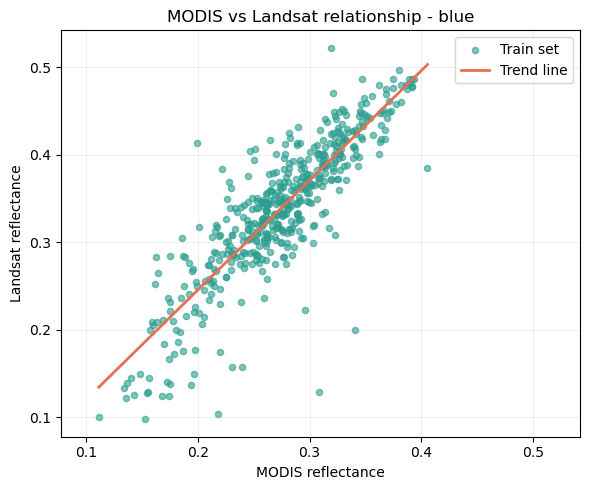

--- blue: Model evaluation ---
Train - R2: 0.74 | MAE: 0.0280 | RMSE: 0.0404
Test  - R2: 0.73 | MAE: 0.0298 | RMSE: 0.0415


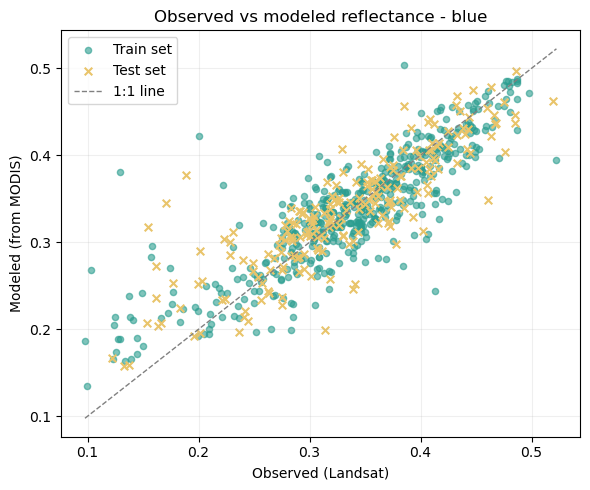

0.040704186482752015

Processing green (722 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     1908.
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          2.59e-173
Time:                        18:25:20   Log-Likelihood:                 923.74
No. Observations:                 505   AIC:                            -1843.
Df Residuals:                     503   BIC:                            -1835.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

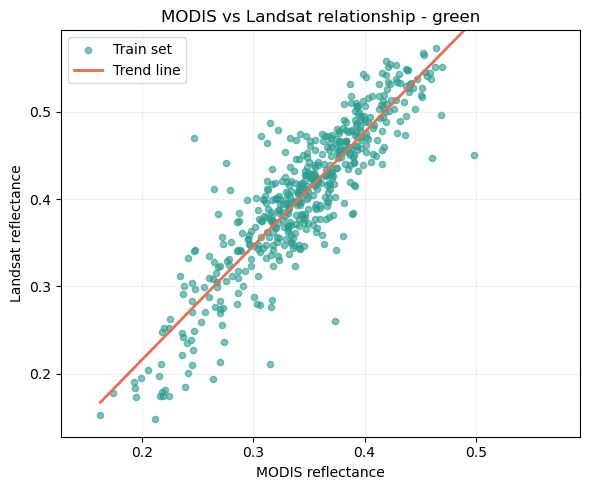

--- green: Model evaluation ---
Train - R2: 0.79 | MAE: 0.0287 | RMSE: 0.0388
Test  - R2: 0.67 | MAE: 0.0321 | RMSE: 0.0477


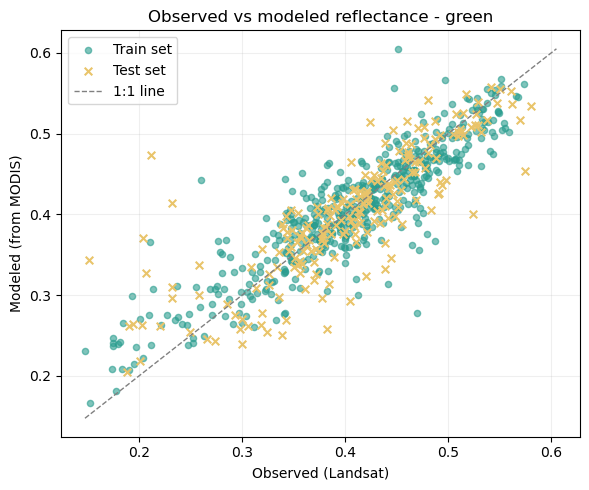

0.04174271964915546

Processing red (695 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1548.
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          7.09e-153
Time:                        18:25:20   Log-Likelihood:                 827.99
No. Observations:                 486   AIC:                            -1652.
Df Residuals:                     484   BIC:                            -1644.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

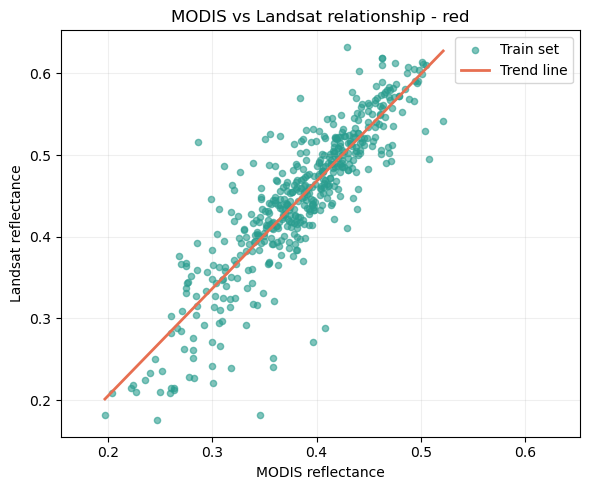

--- red: Model evaluation ---
Train - R2: 0.76 | MAE: 0.0309 | RMSE: 0.0440
Test  - R2: 0.75 | MAE: 0.0313 | RMSE: 0.0401


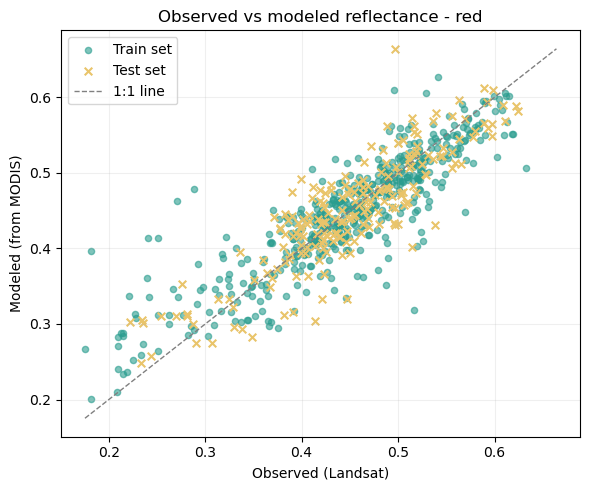

0.04292264674222372

Processing nir (732 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     1527.
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          1.67e-155
Time:                        18:25:20   Log-Likelihood:                 874.54
No. Observations:                 512   AIC:                            -1745.
Df Residuals:                     510   BIC:                            -1737.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

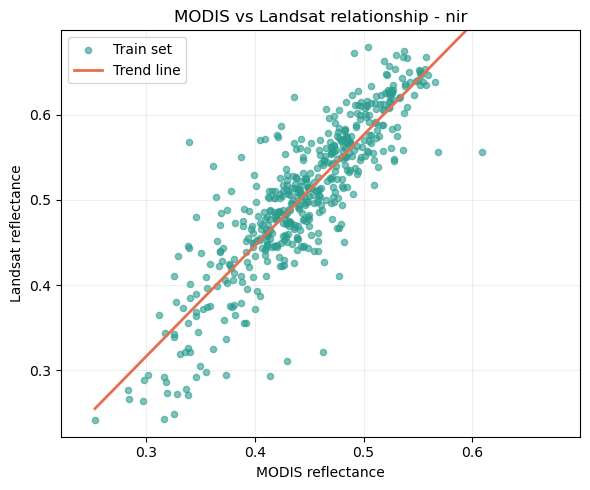

--- nir: Model evaluation ---
Train - R2: 0.75 | MAE: 0.0318 | RMSE: 0.0438
Test  - R2: 0.73 | MAE: 0.0316 | RMSE: 0.0446


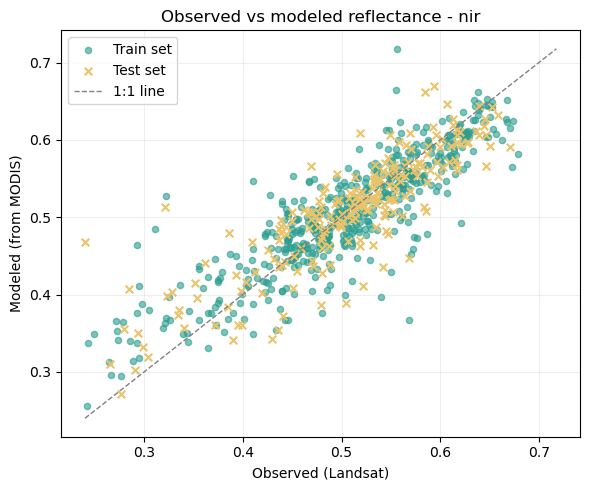

0.04409780570656144

Processing swir1 (732 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     2057.
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          4.34e-181
Time:                        18:25:20   Log-Likelihood:                 879.57
No. Observations:                 512   AIC:                            -1755.
Df Residuals:                     510   BIC:                            -1747.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

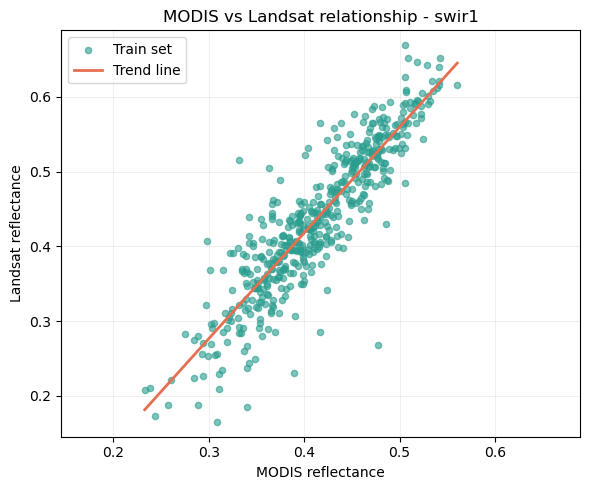

--- swir1: Model evaluation ---
Train - R2: 0.80 | MAE: 0.0312 | RMSE: 0.0434
Test  - R2: 0.78 | MAE: 0.0326 | RMSE: 0.0457


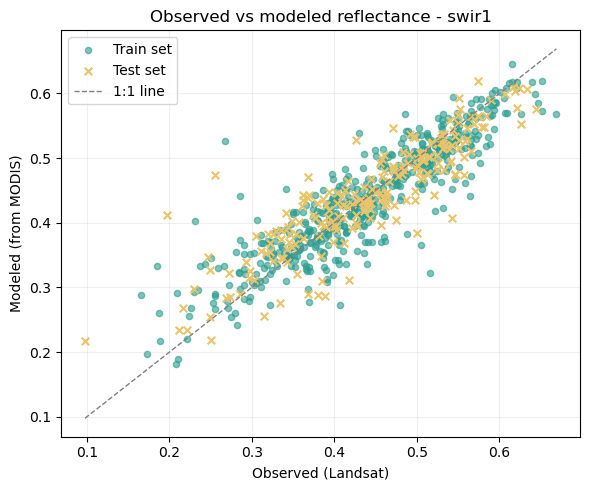

0.04414946186951662

Processing swir2 (735 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     2124.
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          2.43e-184
Time:                        18:25:21   Log-Likelihood:                 854.30
No. Observations:                 514   AIC:                            -1705.
Df Residuals:                     512   BIC:                            -1696.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

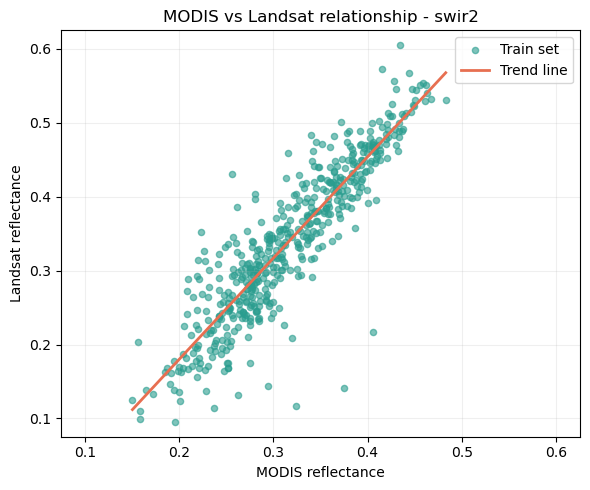

--- swir2: Model evaluation ---
Train - R2: 0.81 | MAE: 0.0322 | RMSE: 0.0459
Test  - R2: 0.76 | MAE: 0.0347 | RMSE: 0.0518


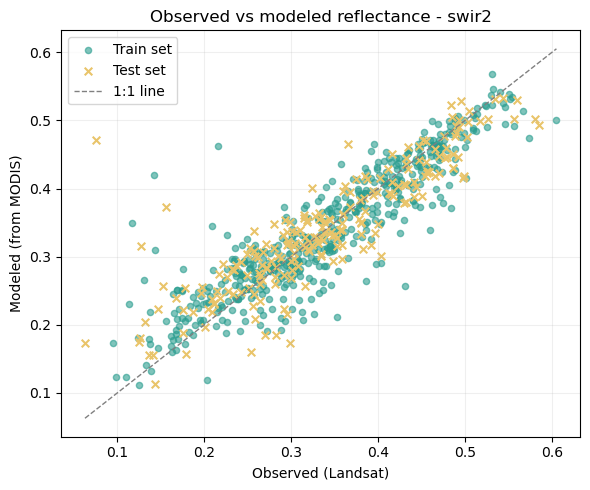

0.047792018565756815


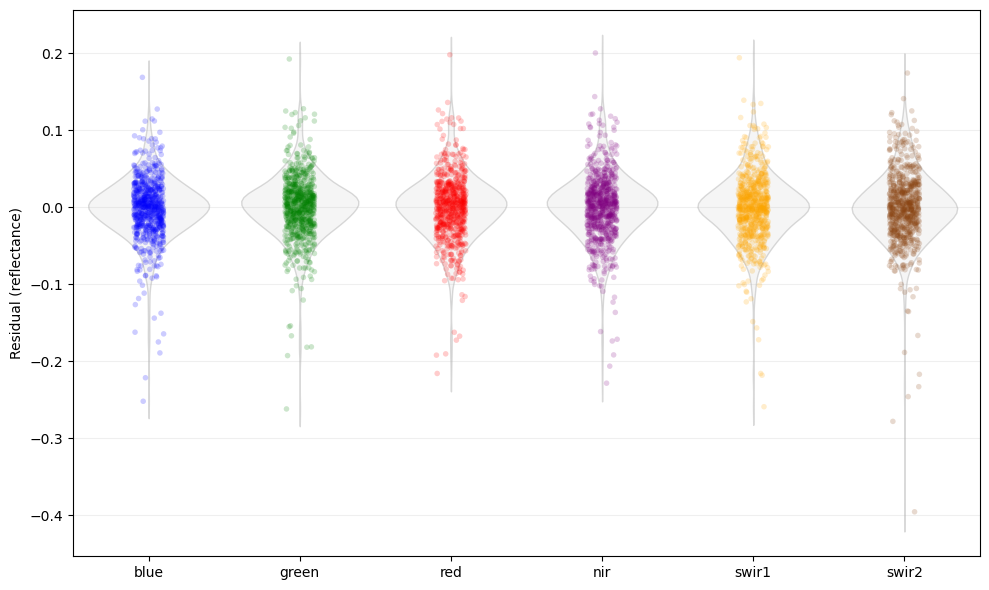

In [2]:
# -----------------------------
# 3. Daily satellite series
# -----------------------------

band_mapping = {
    'blue':  ('blue_mean',  'blue'),
    'green': ('green_mean', 'green'),
    'red':   ('red_mean',   'red'),
    'nir':   ('nir_mean',   'nir'),
    'swir1': ('swir1_mean', 'swir1'),
    'swir2': ('swir2_mean', 'swir2')
}

landsat_daily_df, landsat_residuals_df, landsat_daily_df_anchored, landsat_residuals_df_interpolated = generate_daily_landsat_series(landsat_df, modis_df, band_mapping)
plot_residuals_boxplot(landsat_residuals_df)

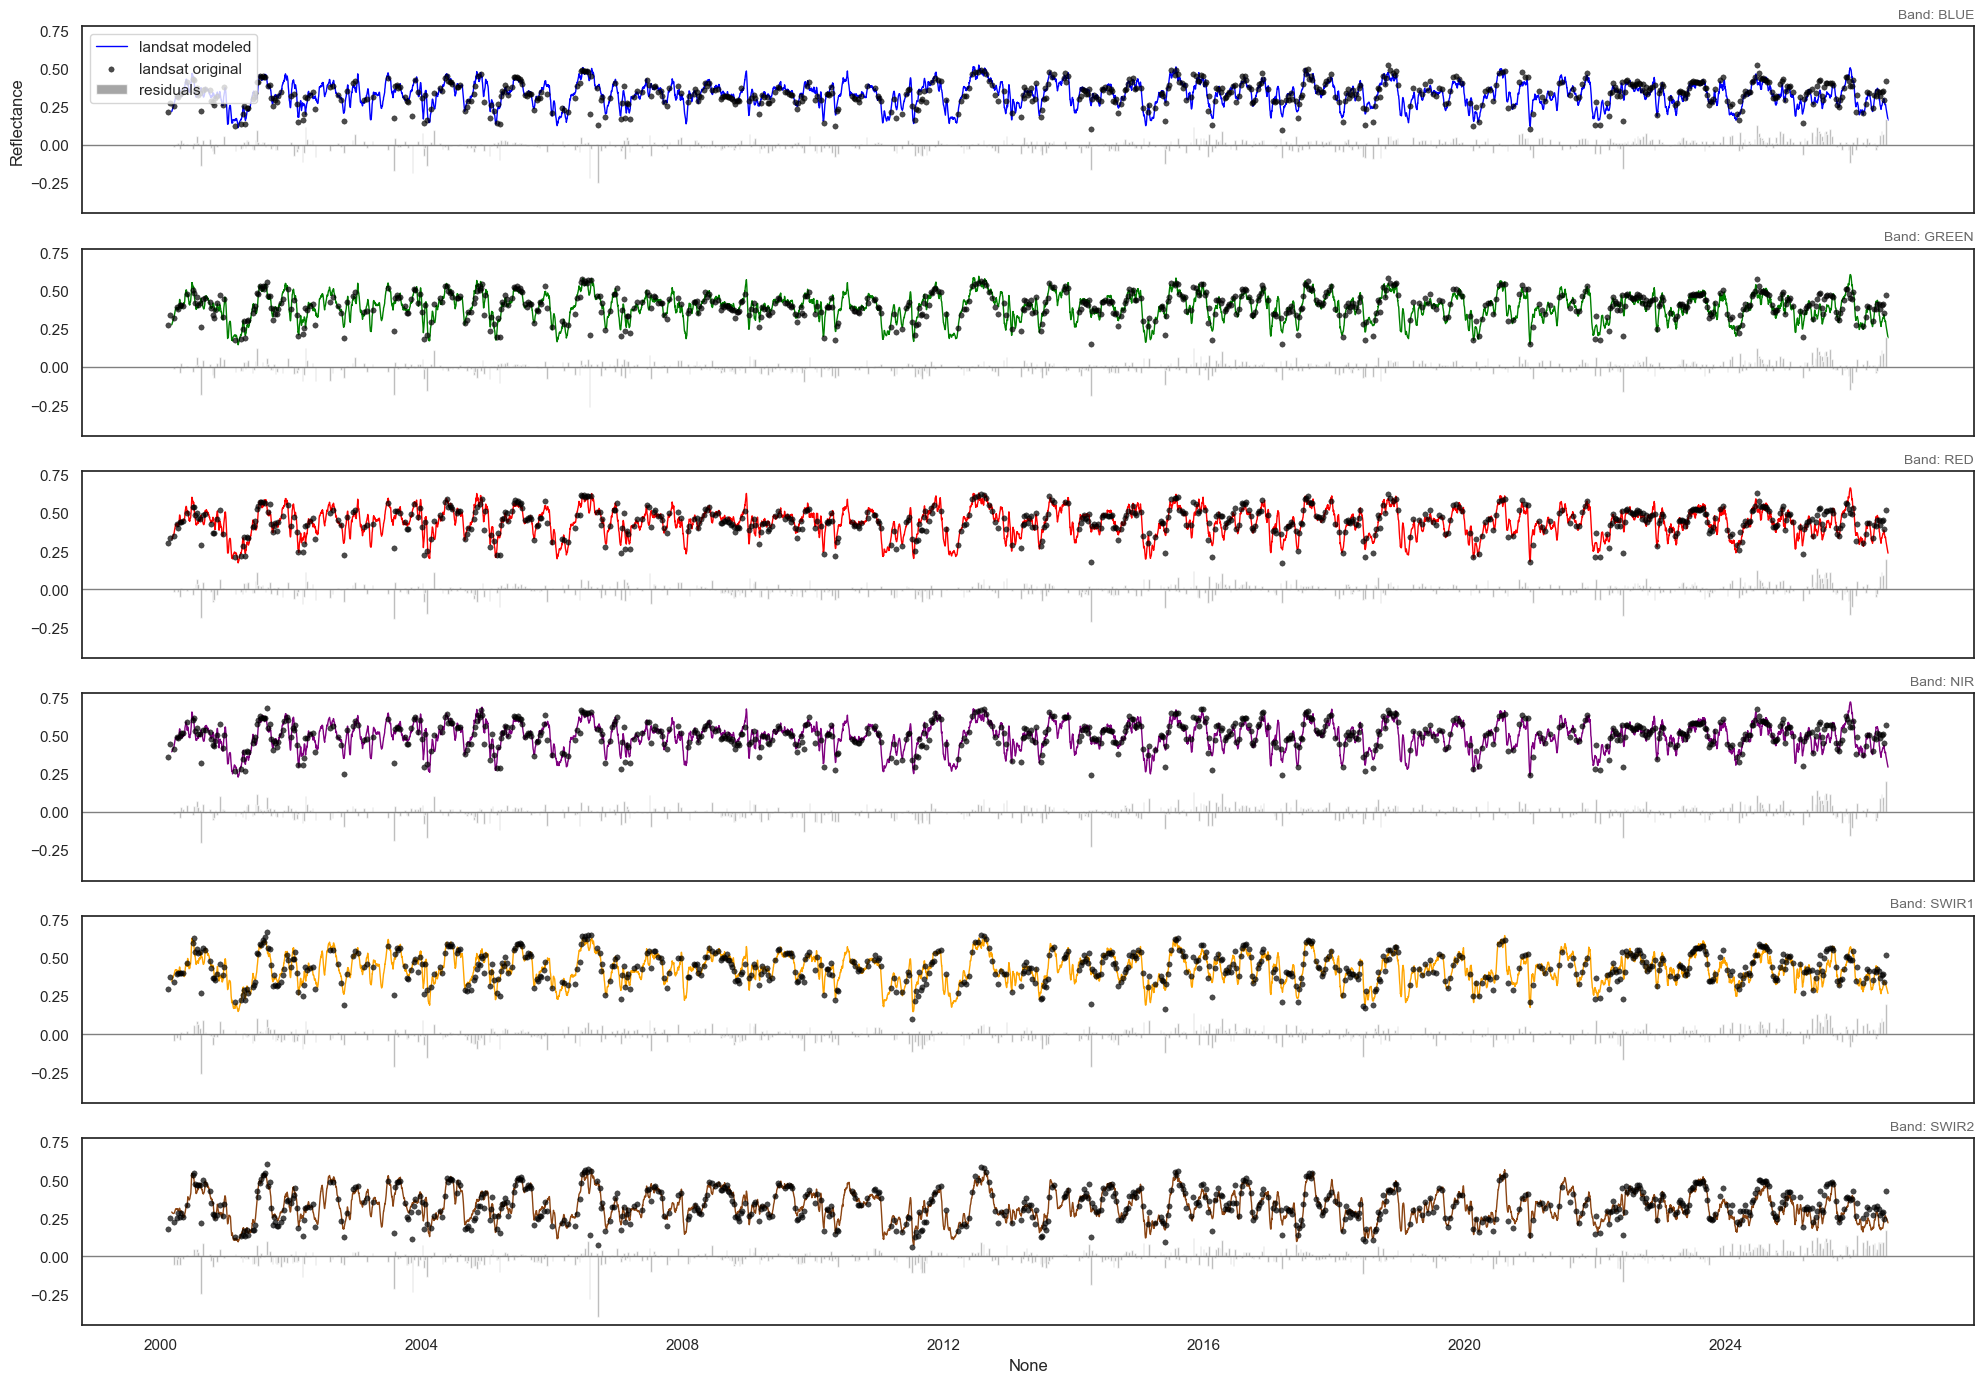

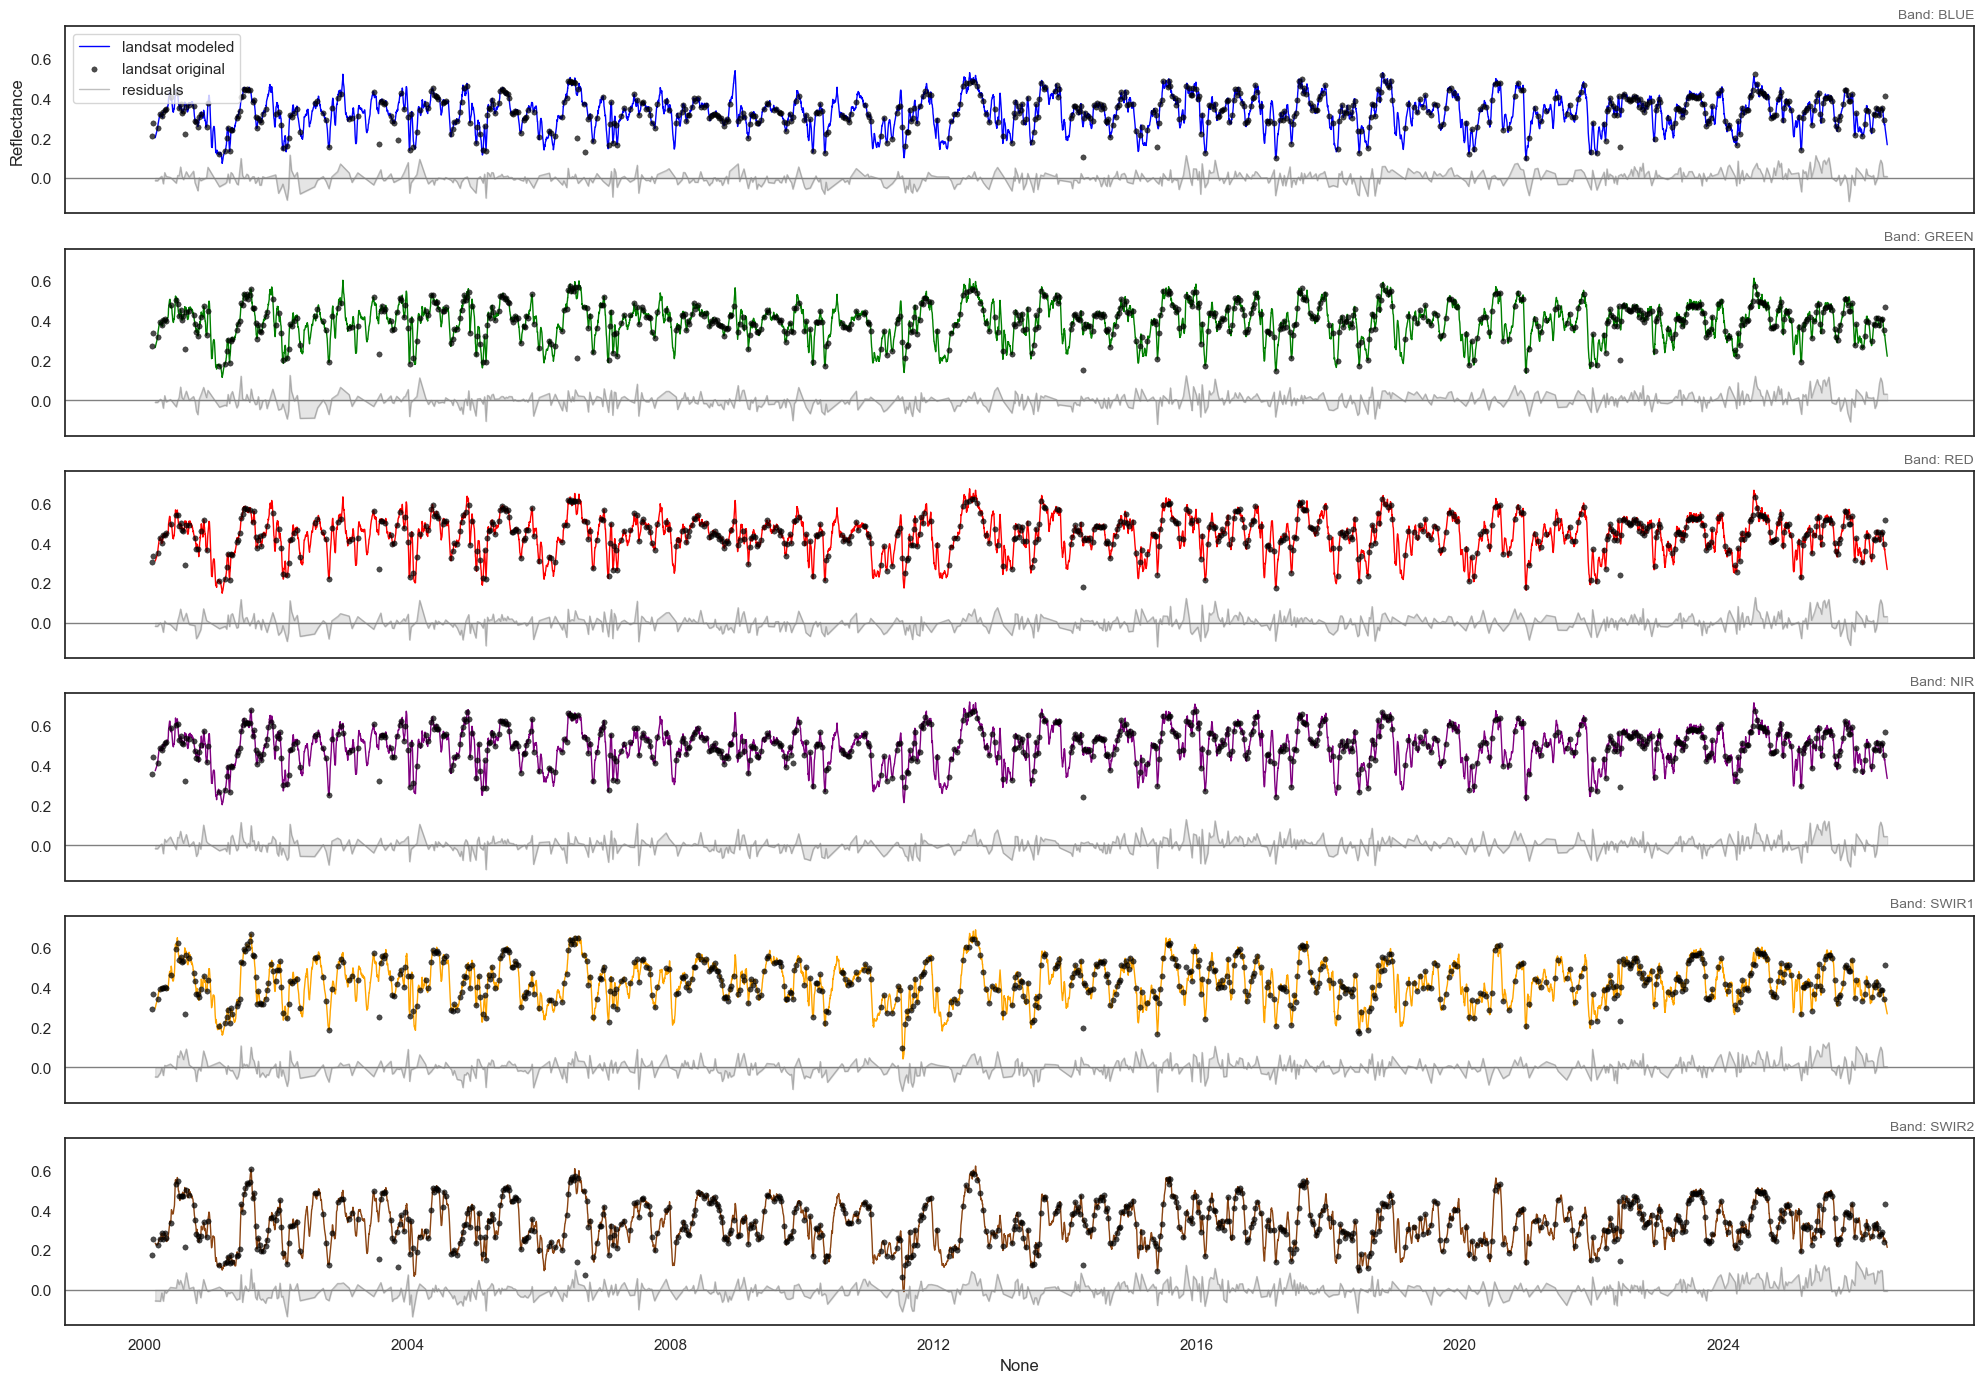

In [3]:
plot_landsat_bands(landsat_daily_df, landsat_df, landsat_residuals_df, start_date, end_date)
plot_landsat_bands(landsat_daily_df_anchored, landsat_df, landsat_residuals_df_interpolated, start_date, end_date)

## Revision de residuales

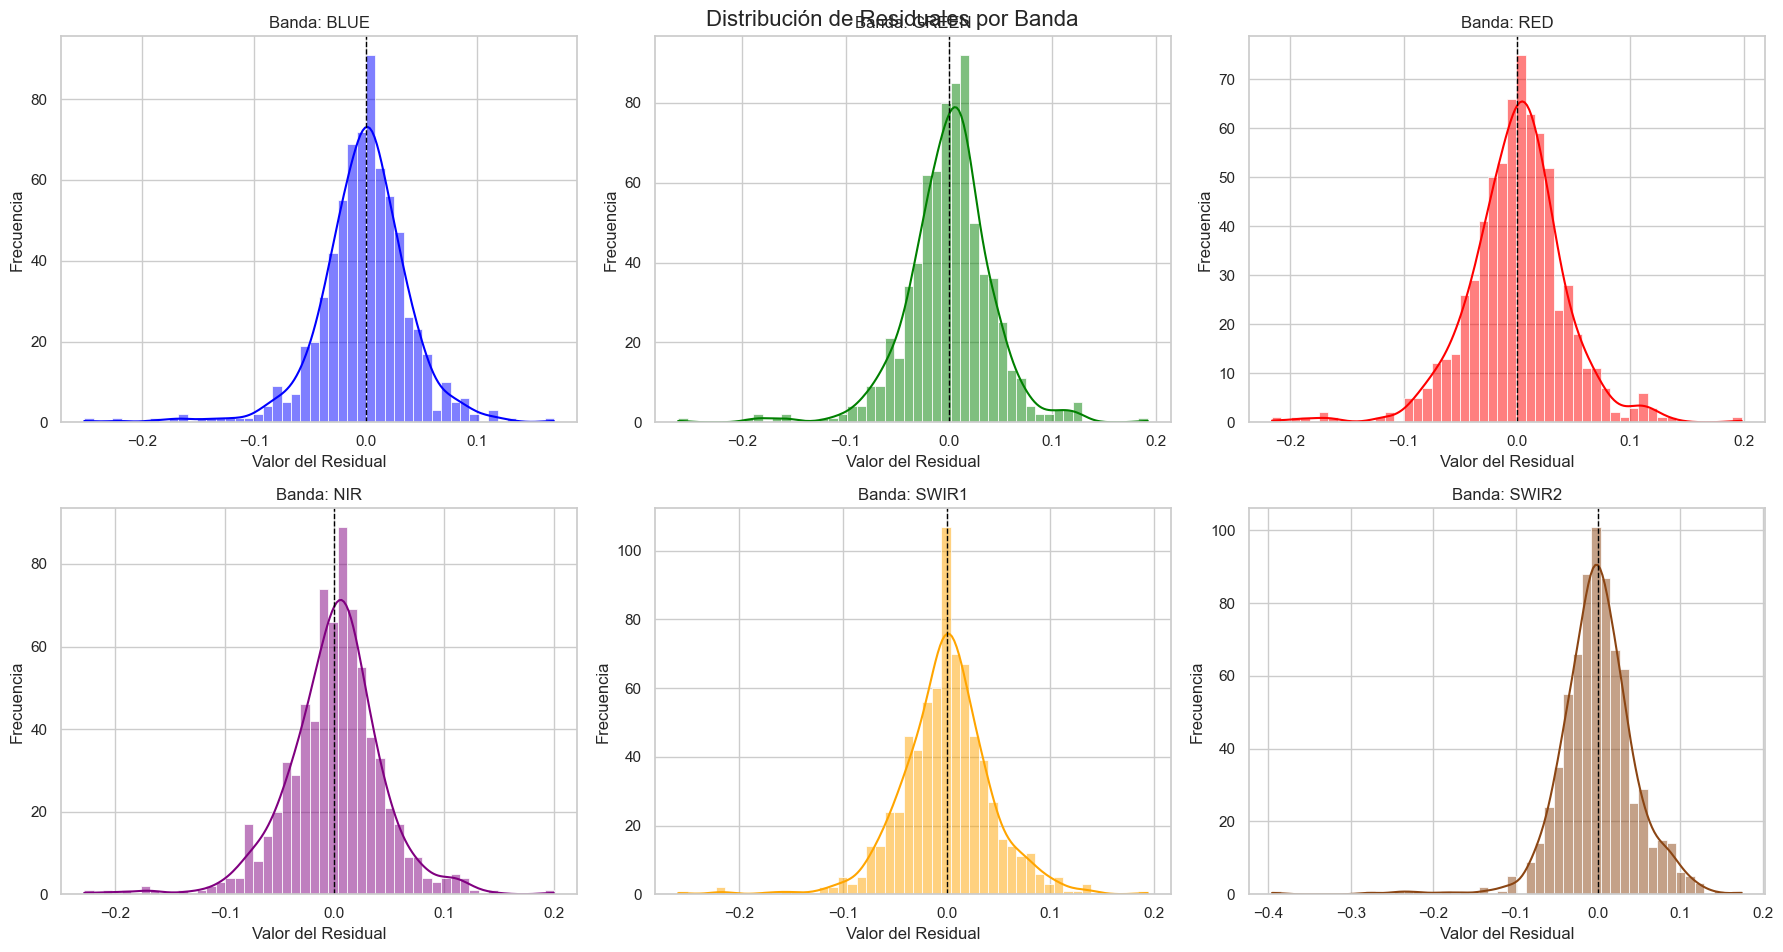

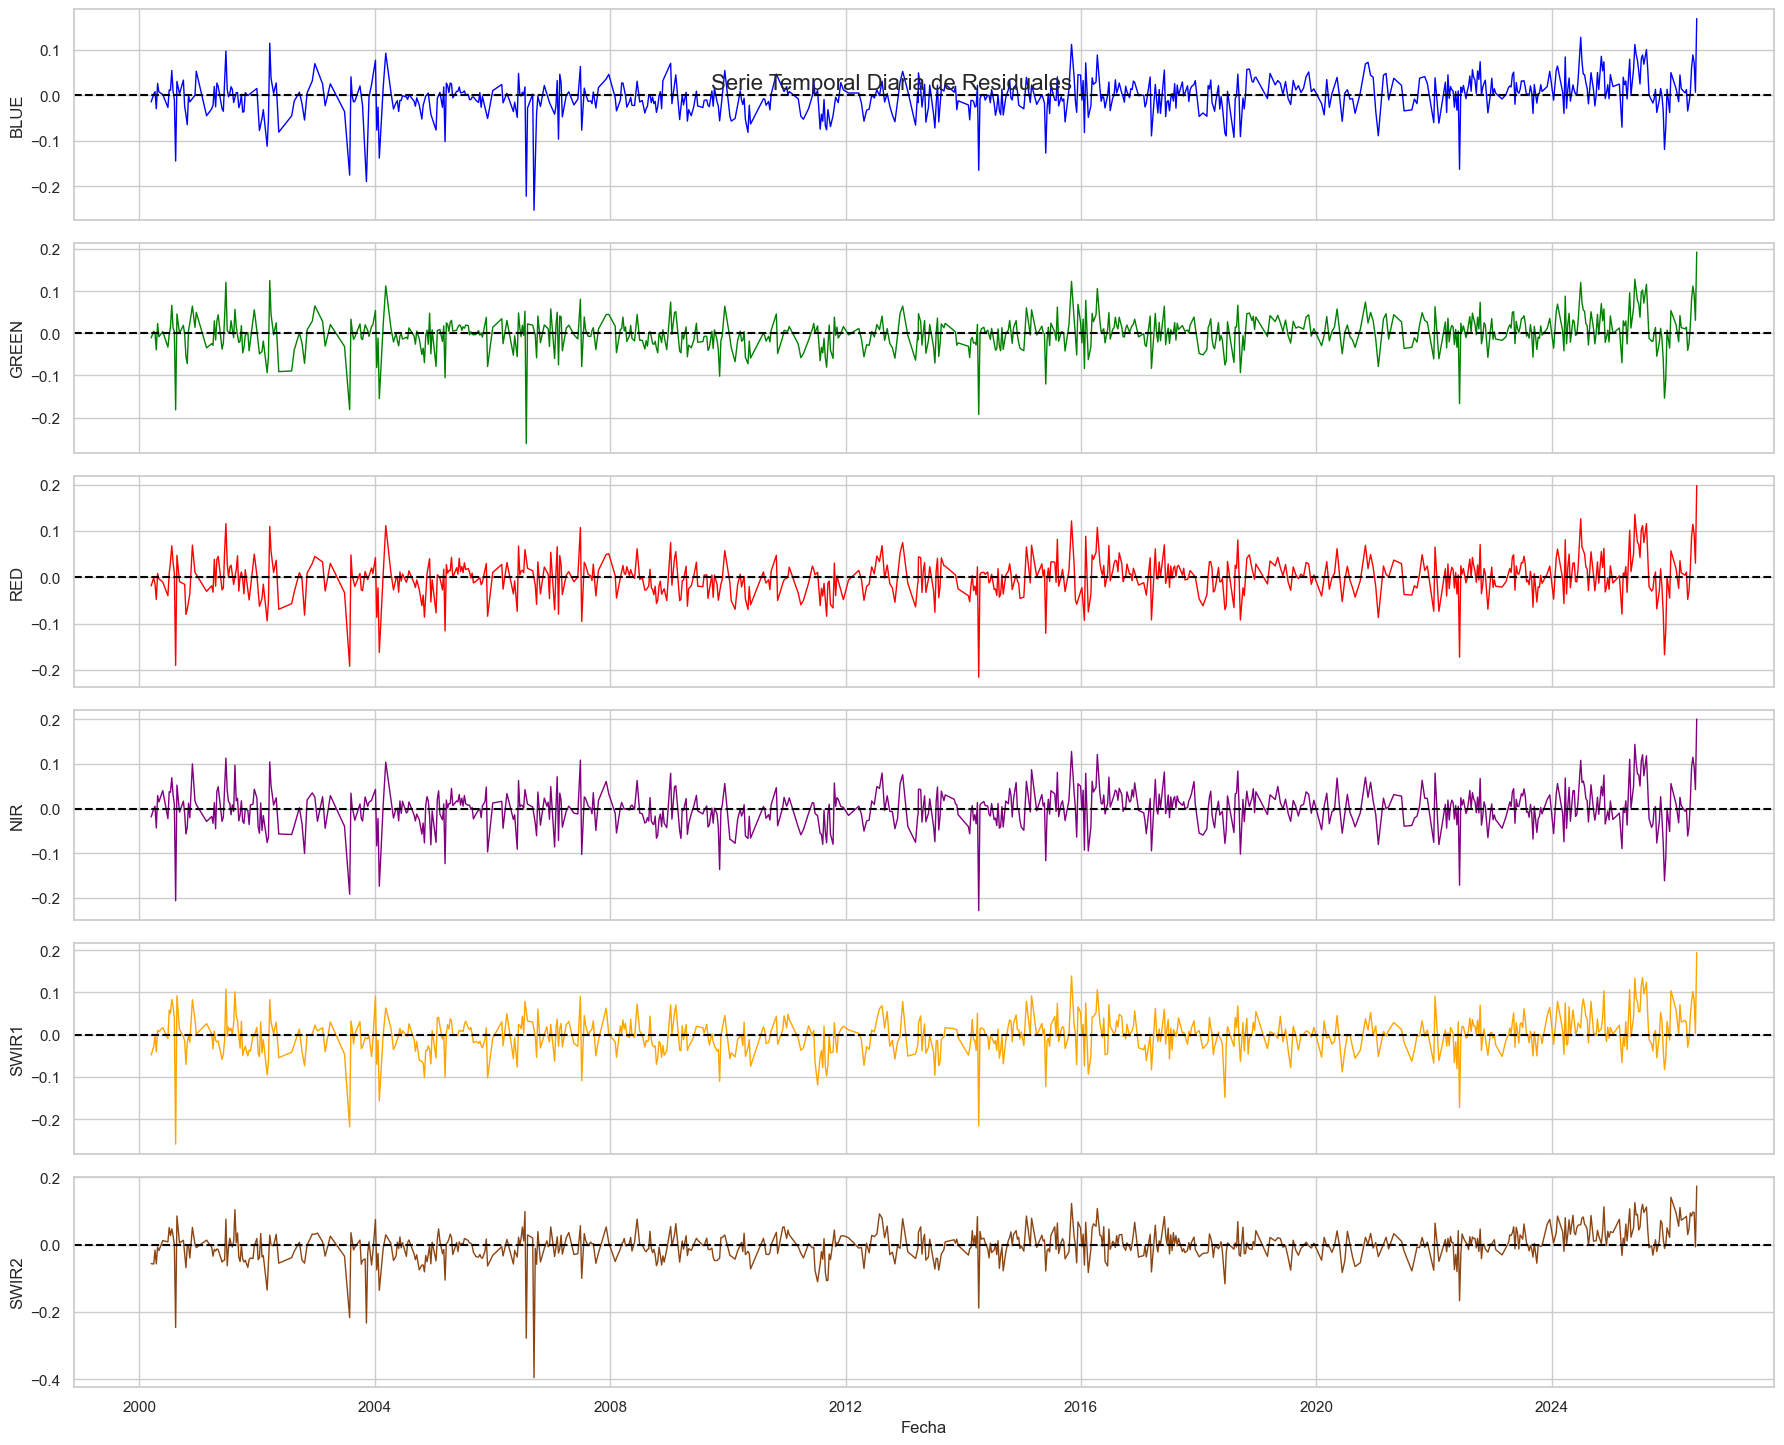

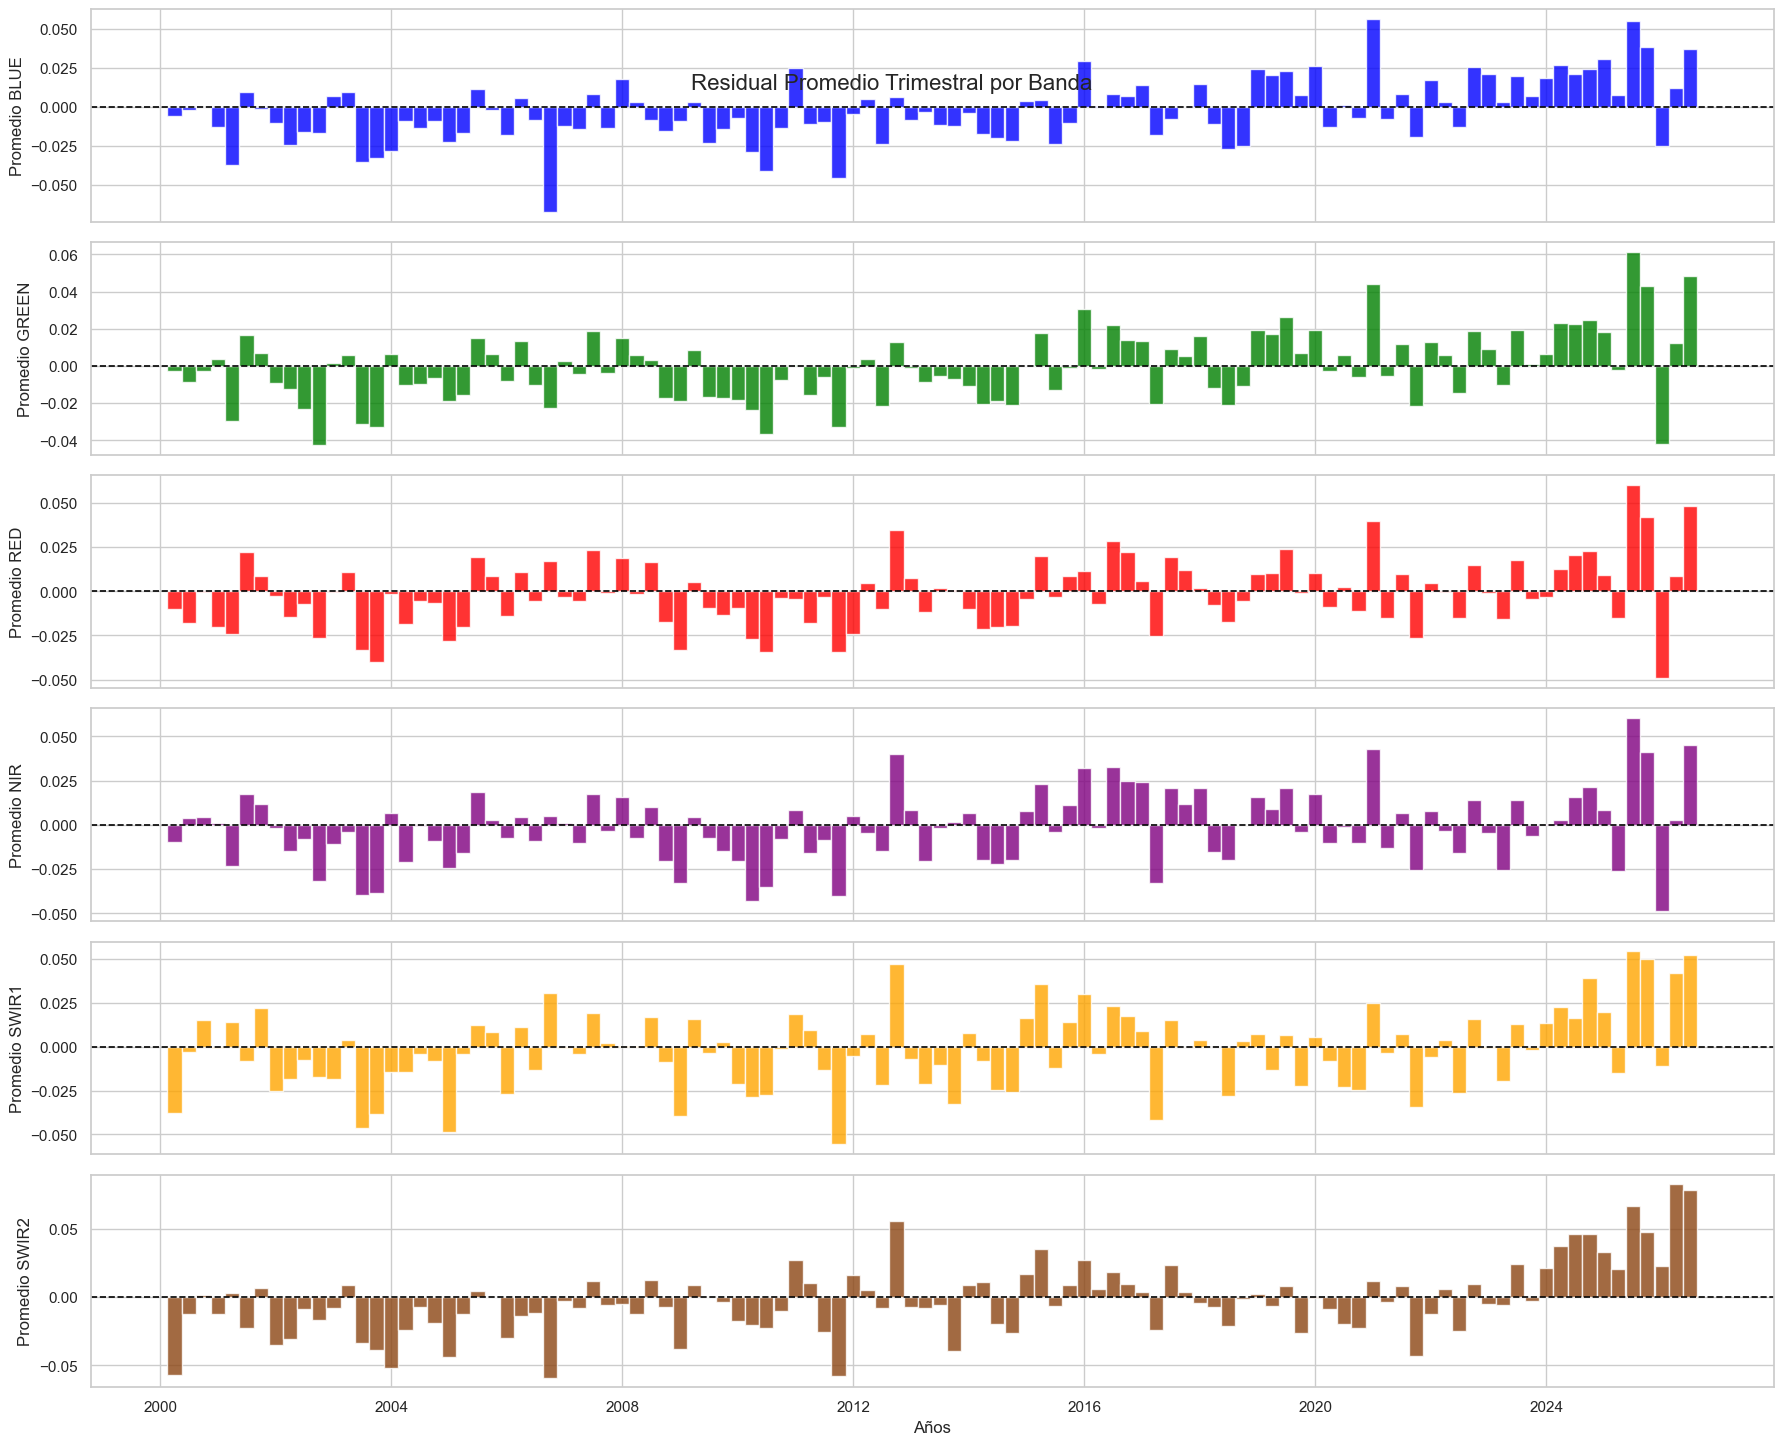

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_landsat_residuals(residuals_df, bands=None, colors=None):
    """
    Genera tres análisis visuales para un DataFrame de residuales:
    1. Histogramas de distribución por banda.
    2. Serie temporal de residuales diarios por banda.
    3. Gráfico de barras de residuales sumados por mes (sin acumulación histórica).
    """
    sns.set_theme(style="whitegrid")
    
    if bands is None:
        bands = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']
    if colors is None:
        colors = ['blue', 'green', 'red', 'purple', 'orange', 'saddlebrown']

    # ==========================================
    # PROCESO 1: Histogramas por banda
    # ==========================================
    fig_hist, axes_hist = plt.subplots(2, 3, figsize=(18, 10))
    fig_hist.suptitle('Distribución de Residuales por Banda', fontsize=16, y=0.95)
    
    for ax, band, color in zip(axes_hist.flatten(), bands, colors):
        sns.histplot(data=residuals_df, x=band, color=color, kde=True, bins=50, ax=ax)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'Banda: {band.upper()}')
        ax.set_xlabel('Valor del Residual')
        ax.set_ylabel('Frecuencia')
        
    plt.tight_layout()
    plt.show()

    # ==========================================
    # PROCESO 2: Serie Temporal por Banda
    # ==========================================
    fig_ts, axes_ts = plt.subplots(len(bands), 1, figsize=(18, 15), sharex=True)
    fig_ts.suptitle('Serie Temporal Diaria de Residuales', fontsize=16, y=0.92)
    
    for ax, band, color in zip(axes_ts, bands, colors):
        sns.lineplot(x=residuals_df.index, y=residuals_df[band], color=color, ax=ax, linewidth=1)
        ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
        ax.set_ylabel(f'{band.upper()}')
        
    axes_ts[-1].set_xlabel('Fecha')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # PROCESO 3: Promedio Trimestral de Residuales (Barras)
    # ==========================================
    try:
        yearly_mean_df = residuals_df[bands].resample('3ME').mean()
    except ValueError:
        yearly_mean_df = residuals_df[bands].resample('3M').mean()

    fig_bars, axes_bars = plt.subplots(len(bands), 1, figsize=(18, 15), sharex=True)
    fig_bars.suptitle('Residual Promedio Trimestral por Banda', fontsize=16, y=0.92)
    
    for ax, band, color in zip(axes_bars, bands, colors):
        ax.bar(yearly_mean_df.index, yearly_mean_df[band], color=color, width=90, alpha=0.8)
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1.2)
        ax.set_ylabel(f'Promedio {band.upper()}')
        
    axes_bars[-1].set_xlabel('Años')
    plt.tight_layout()
    plt.show()

# --- Ejemplo de ejecución ---
analyze_landsat_residuals(landsat_residuals_df)


## Revision de desempeño de modelos en diferentes periodos

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from code.v2_data_preprocessing import slice_by_dates

def get_coincident_data(s_landsat, s_modis):
    """
    Alinea las series de Landsat y MODIS por su DatetimeIndex 
    y extrae las observaciones válidas coincidentes.
    """
    df_aligned = pd.concat([s_landsat, s_modis], axis=1, keys=['landsat', 'modis'])
    return df_aligned.dropna()


def train_and_evaluate_model(df_coincident, test_size=0.3, random_state=42):
    """
    Divide los datos, entrena el modelo de regresión lineal 
    y retorna los valores de R2 para los sets de Train y Test.
    """
    X = df_coincident[['modis']].values
    y = df_coincident['landsat'].values
    
    # Dividir los datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # Entrenar el modelo
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predicciones
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calcular R2
    r2_tr = r2_score(y_train, y_train_pred)
    r2_te = r2_score(y_test, y_test_pred)
    
    return r2_tr, r2_te


def evaluate_periods_r2(df_landsat, df_modis, band_mapping, periods):
    """
    Ejecuta las regresiones iterando sobre una lista de periodos y bandas,
    retornando un DataFrame con el R2 de entrenamiento y prueba.
    
    Parámetros:
    - periods: lista de tuplas con las fechas de inicio y fin, ej: [('2000', '2005'), ('2000', '2010')]
    """
    results = []
    
    for start_date, end_date in periods:
        period_label = f"{start_date} - {end_date}"
        print(f"Procesando periodo: {period_label}...")
        
        # Filtrar datos para el periodo actual
        df_l_sliced = slice_by_dates(df_landsat, start_date, end_date)
        df_m_sliced = slice_by_dates(df_modis, start_date, end_date)
        
        for band_name, (landsat_col, modis_col) in band_mapping.items():
            
            # Validar existencia de columnas
            if landsat_col not in df_l_sliced.columns or modis_col not in df_m_sliced.columns:
                continue
                
            s_landsat = df_l_sliced[landsat_col]
            s_modis = df_m_sliced[modis_col]
            
            # Extraer datos coincidentes
            df_coincident = get_coincident_data(s_landsat, s_modis)
            
            # Chequeo de seguridad: Evitar error si hay muy pocos datos para el train_test_split
            if len(df_coincident) < 10: 
                r2_tr, r2_te = np.nan, np.nan
            else:
                r2_tr, r2_te = train_and_evaluate_model(df_coincident)
                
            # Almacenar resultados
            results.append({
                'Period': period_label,
                'Band': band_name,
                'R2_Train': r2_tr,
                'R2_Test': r2_te,
                'N_Obs': len(df_coincident) # Opcional: útil para saber si el R2 cayó por falta de datos
            })
            
    return pd.DataFrame(results)


def plot_r2_results(df_results):
    """
    Genera un panel de gráficos de barras para comparar el R2 (Train vs Test) 
    para cada banda en los distintos periodos iterados.
    """
    # Reestructurar el DF para Seaborn (Melt)
    df_melted = df_results.melt(
        id_vars=['Period', 'Band'], 
        value_vars=['R2_Train', 'R2_Test'], 
        var_name='Dataset', 
        value_name='R2'
    )
    
    # Limpiar los nombres de la leyenda
    df_melted['Dataset'] = df_melted['Dataset'].str.replace('R2_', '')
    
    sns.set_theme(style="whitegrid")
    
    # Crear un gráfico facetado (un subgráfico por banda)
    g = sns.catplot(
        data=df_melted, kind="bar",
        x="Period", y="R2", hue="Dataset", col="Band", col_wrap=3,
        palette=["#2A9D8F", "#E9C46A"], # Colores originales mantenidos
        height=4, aspect=1.3, alpha=0.9
    )
    
    # Configurar etiquetas y títulos
    g.set_axis_labels("Período", "R² Score")
    g.set_titles("Banda: {col_name}")
    g.set(ylim=(0, 1)) # R2 asume valores entre 0 y 1 idealmente
    
    # Rotar las etiquetas del eje X si son muy largas
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')
    
    # Título principal
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle('Evaluación de R² (Landsat vs MODIS) por Período y Banda', fontsize=16)
    
    plt.show()


Procesando periodo: 2000 - 2026...
Procesando periodo: 2000 - 2022...
Procesando periodo: 2000 - 2003...
Procesando periodo: 2004 - 2007...
Procesando periodo: 2008 - 2011...
Procesando periodo: 2012 - 2015...
Procesando periodo: 2016 - 2018...
Procesando periodo: 2019 - 2022...
Procesando periodo: 2023 - 2026...


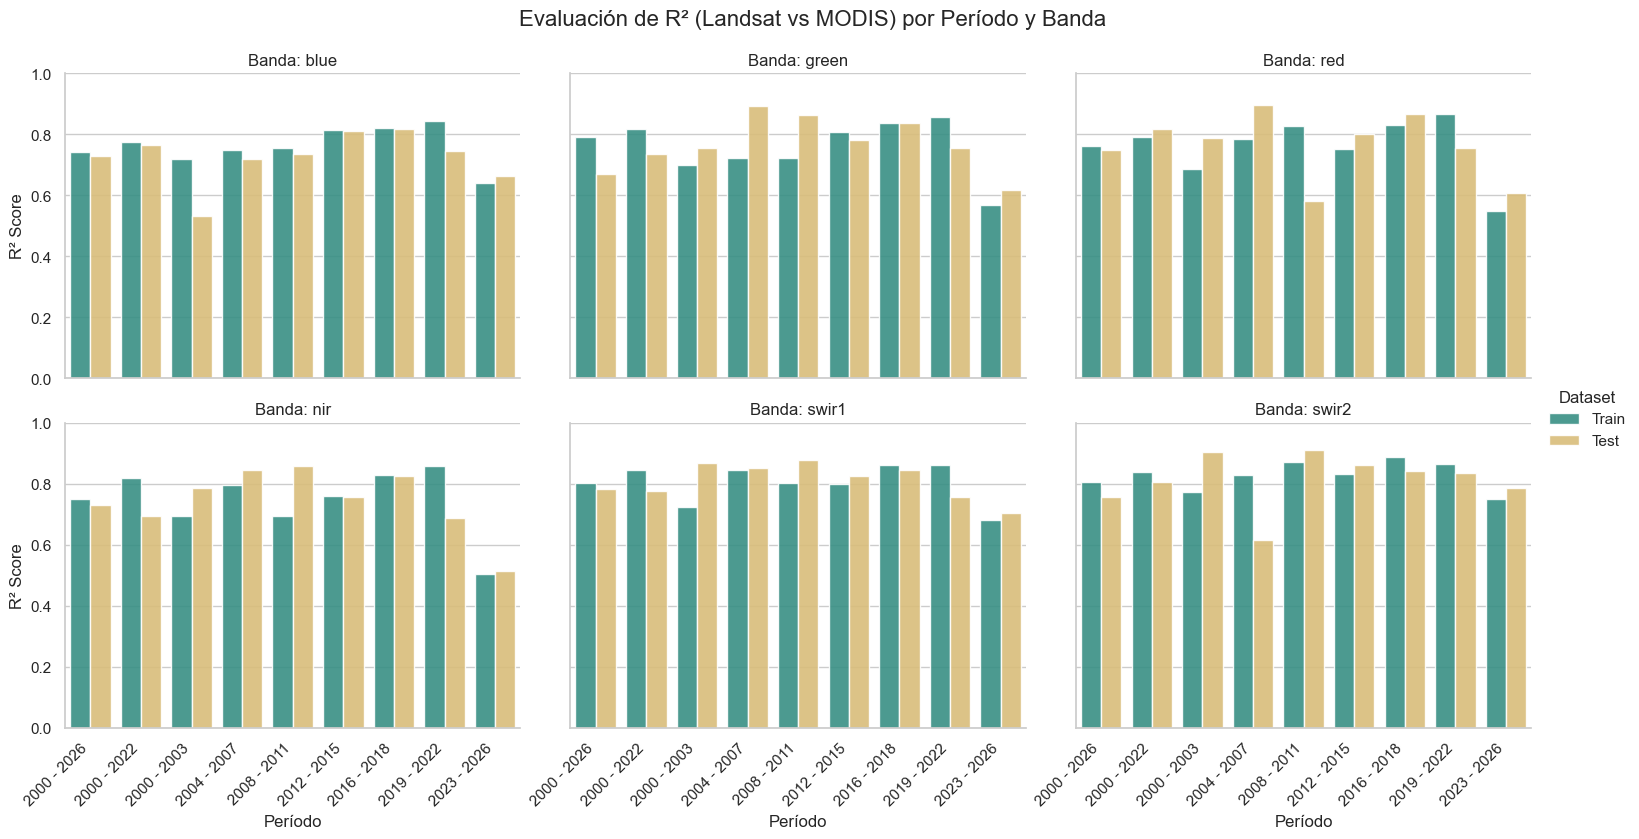

Procesando periodo: 2000 - 2026...
Procesando periodo: 2002 - 2012...
Procesando periodo: 2013 - 2022...


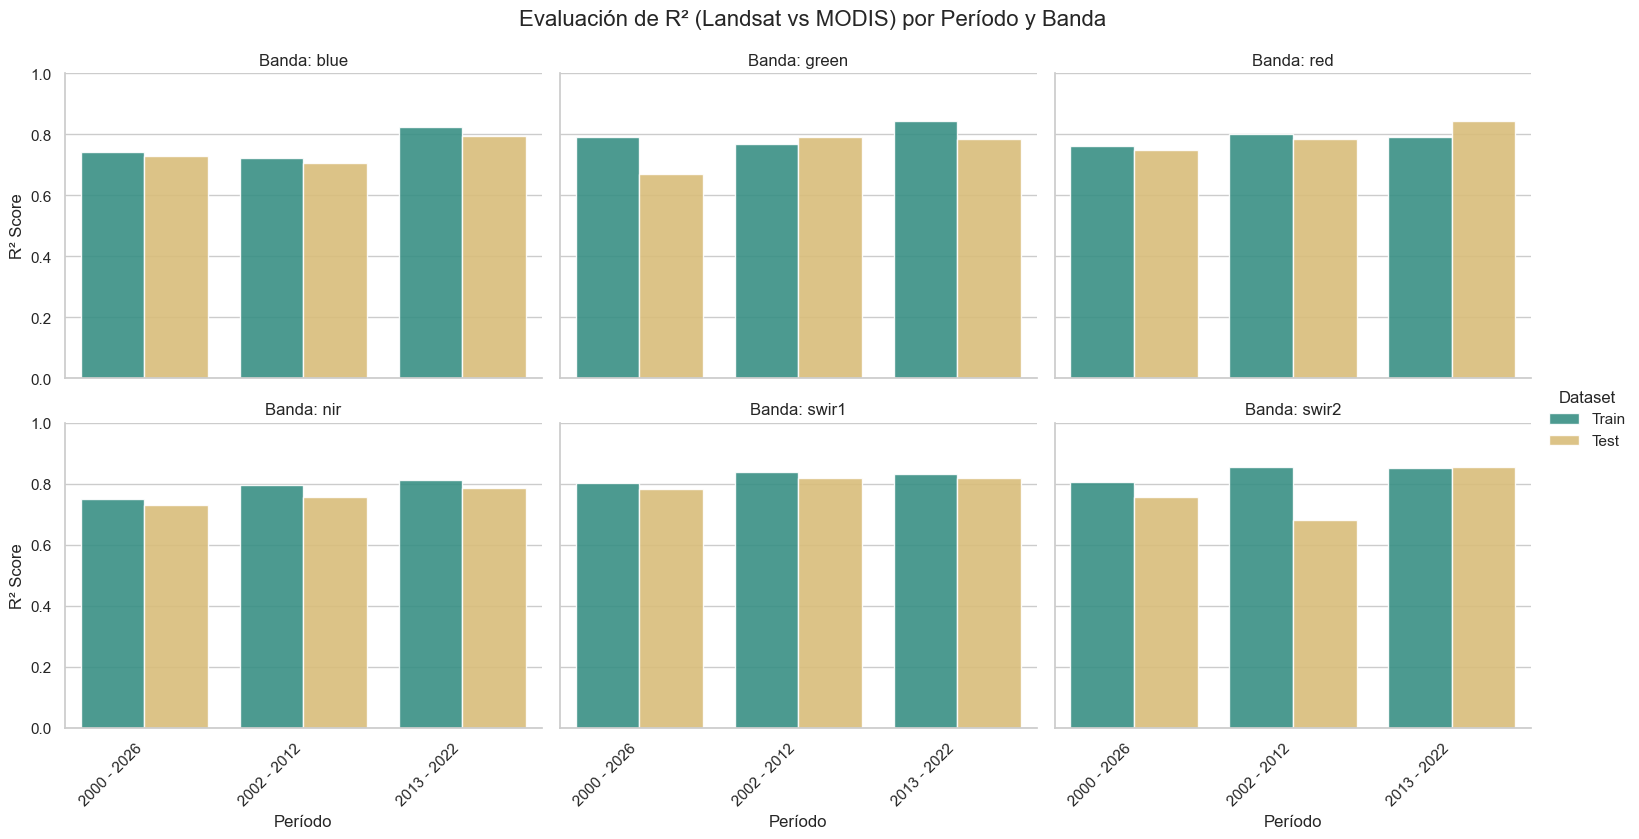

In [13]:
# # evaluacion de cambios en orbita modis
# periods = [
#     ('2000', '2002'),   # periodo inicial
#     ('2003', '2019'),   # orbita estable
#     ('2020', '2022'),   # primeras desviaciones
#     ('2023', '2026'),   # descenso de orbita
#     ]

# evaluacion cada ~4 años
periods4 = [
    ('2000', '2026'),
    ('2000', '2022'),
    ('2000', '2003'),
    ('2004', '2007'),
    ('2008', '2011'),
    ('2012', '2015'),   
    ('2016', '2018'),   # 3 años por ser el periodo con mejores resultados
    ('2019', '2022'),
    ('2023', '2026'),
    ]

# evaluacion a largo plazo
periods_lt = [
    ('2000', '2026'),
    ('2002', '2012'),
    ('2013', '2022'),
    ]

# #evaluacion cada 3 años
# periods = [
#     ('2000', '2002'),
#     ('2003', '2005'),
#     ('2006', '2008'),
#     ('2009', '2011'),
#     ('2012', '2014'),
#     ('2015', '2017'),
#     ('2018', '2020'),
#     ('2021', '2023'),
#     ('2024', '2026'),
#     ]

r2_df_p4 = evaluate_periods_r2(landsat_df, modis_df, band_mapping, periods4)
plot_r2_results(r2_df_p4)

r2_df_lt = evaluate_periods_r2(landsat_df, modis_df, band_mapping, periods_lt)
plot_r2_results(r2_df_lt)